# Morandini layer sweep

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
sys.path.append('../../deconversation')
from pseudobulk import *
from preprocessing import *
from embeddings_1 import *
from deconvolution import *
from visualization import *

geneformer successfully imported.
cell2sentence is not installed. Skipping related functions.
cellhermes is not installed. Skipping related functions.
scGPT is not installed. Skipping related functions.
scVI successfully imported.


In [2]:
dataset_name = 'morandini'
reference_path = '/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/hao800_signature_matrix_broad_id.csv'
bulk_path = '/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/bulk/morandini/morandini_tpm_id_transpose.csv'
ground_truth_path = '/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/bulk/morandini/morandini_facs.csv'

signature_df = pd.read_csv(reference_path, index_col=0)
signature_df = signature_df.T

bulk_df = pd.read_csv(bulk_path, index_col=0)
bulk_df = bulk_df.loc[bulk_df.index.dropna()]

ground_truth = pd.read_csv(ground_truth_path, index_col=0)
ground_truth = ground_truth.T

In [3]:
ground_truth.head()

,Monocytes,Granulocytes,Lymphocytes,B cells,NK cells,T cells,T cells CD4,T cells CD8
GSM5774456,0.113,0.0037,0.828,0.0754,0.0956,0.571,0.360,0.1180
GSM5774457,0.153,0.0055,0.785,0.0724,0.1780,0.405,0.223,0.1270
GSM5774458,0.117,0.0091,0.797,0.0552,0.1590,0.469,0.287,0.0581
GSM5774459,0.120,0.0072,0.780,0.0935,0.1210,0.369,0.196,0.0764
GSM5774460,0.112,0.0115,0.839,0.0388,0.0417,0.538,0.241,0.1160


In [4]:
def harmonize_columns(df):
    df = df.copy()
    if 'T cells CD8' in df.columns and 'T cells CD4' in df.columns:
        df['T cells'] = df['T cells CD8'] + df['T cells CD4']
        df = df.drop(columns=['T cells CD8', 'T cells CD4'])
    keep = [c for c in ['T cells', 'Monocytes', 'B cells', 'NK cells'] if c in df.columns]
    return df[keep]

In [5]:
ground_truth = harmonize_columns(ground_truth)

In [6]:
bulk_df.head()

,ENSG00000223972,ENSG00000227232,ENSG00000278267,ENSG00000243485,ENSG00000284332,ENSG00000237613,ENSG00000186092,ENSG00000279928,ENSG00000279457,ENSG00000273874,...,ENSG00000187191,ENSG00000205916,ENSG00000185894,ENSG00000228296,ENSG00000223641,ENSG00000172297,ENSG00000240450,ENSG00000172288,ENSG00000231141,ENSG00000235014
sample,,,,,,,,,,,,,,,,,,,,,
GSM5774456,2.004,49.78,45.20,0.0,0.0,0.0,0.0,2.060,52.76,33.03,...,0.0,0.0,0,0,0,0.0,0.0,0,0.0,0.0
GSM5774457,1.175,71.57,32.63,0.0,0.0,0.0,0.0,1.726,86.46,20.39,...,0.0,0.0,0,0,0,0.0,0.0,0,0.0,0.0
GSM5774458,4.497,87.02,60.50,0.0,0.0,0.0,0.0,6.401,85.15,33.61,...,0.0,0.0,0,0,0,0.0,0.0,0,0.0,0.0
GSM5774459,4.921,57.35,35.07,0.0,0.0,0.0,0.0,8.769,53.00,22.32,...,0.0,0.0,0,0,0,0.0,0.0,0,0.0,0.0
GSM5774460,1.871,81.60,48.82,0.0,0.0,0.0,0.0,3.134,86.78,25.25,...,0.0,0.0,0,0,0,0.0,0.0,0,0.0,0.0


### Zero_Shot

In [7]:
layer_results = {}
metric_rows = []
celltype_rows = []
for layer in range(1, 19):
    print(f'=== layer {layer} ===', flush=True)
    sig_mat_gf_embed = extract_embs(
        bulk_df=signature_df.T,
        mode='geneformer',
        temp_output_dir='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/',
        model_path='ctheodoris/Geneformer',
        delete_temp_files=True,
        layer_to_quant=layer,
    )
    gf_embed = extract_embs(
        bulk_df=bulk_df,
        mode='geneformer',
        temp_output_dir='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/',
        model_path='ctheodoris/Geneformer',
        delete_temp_files=True,
        layer_to_quant=layer,
    )
    results = run_all_deconv(bulk_df=gf_embed.T, signature_df=sig_mat_gf_embed.T)
    results = {solver: harmonize_columns(df) for solver, df in results.items()}
    layer_results[layer] = results
    for solver, df in results.items():
        samples = df.index.intersection(ground_truth.index)
        celltypes = df.columns.intersection(ground_truth.columns)
        P = df.loc[samples, celltypes].astype(float)
        T = ground_truth.loc[samples, celltypes].astype(float)
        p = P.values.ravel()
        t = T.values.ravel()
        ok = np.isfinite(p) & np.isfinite(t)
        for ct in celltypes:
            a = P[ct].values
            b = T[ct].values
            m = np.isfinite(a) & np.isfinite(b)
            if m.sum() > 1 and np.std(a[m]) > 0 and np.std(b[m]) > 0:
                r_ct = np.corrcoef(a[m], b[m])[0, 1]
            else:
                r_ct = np.nan
            celltype_rows.append({'layer': layer, 'solver': solver, 'celltype': ct, 'correlation': r_ct, 'rmse': np.sqrt(np.mean((a[m] - b[m]) ** 2)) if m.sum() else np.nan})
        ct_sub = [r for r in celltype_rows if r['layer'] == layer and r['solver'] == solver]
        corrs = np.array([r['correlation'] for r in ct_sub], dtype=float)
        mean_corr = np.mean(np.nan_to_num(corrs, nan=0.0))
        mean_rmse = np.nanmean([r['rmse'] for r in ct_sub])
        metric_rows.append({'layer': layer, 'solver': solver, 'correlation': np.corrcoef(p[ok], t[ok])[0, 1], 'rmse': np.sqrt(np.mean((p[ok] - t[ok]) ** 2)), 'meanCorrelation': mean_corr, 'meanRMSE': mean_rmse})

metrics_df = pd.DataFrame(metric_rows)
celltype_df = pd.DataFrame(celltype_rows)

metrics_df.to_csv('../../results/gf_layer_sweep/layer_sweep_metrics_zeroshot_morandini.csv', index=False)

=== layer 1 ===
Pseudobulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 28.04it/s]
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:787: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/geneformer/tokenizer.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a va

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.
Loading Geneformer model...


CLS token present in token dictionary, excluding from average.
EOS token present in token dictionary, excluding from average.


Loading tokenized dataset...
Extracting Geneformer embeddings...


...

Loading Geneformer model...
Loading tokenized dataset...
Extracting Geneformer embeddings...


  0%|          | 0/4 [00:00<?, ?it/s]

Condition number: 11.63.
~1-10: signatures are well separated; NNLS is usually hard to improve materially with another solver.
Smallest singular value: 0.1985.
If value is close to zero, the signature matrix is ill-conditioned; estimated proportions may be unstable.
Max pairwise cosine similarity between cell types: 0.9570.
Most similar pair: NK cells vs T cells.
If value is close to 1, these cell types are highly similar and difficult to resolve separately.
Running solver: nnls
Finished in 0.02 seconds.
Running solver: nnls_mod
Finished in 0.02 seconds.
Running solver: dwls
Finished in 0.11 seconds.
Running solver: simplex
Finished in 0.13 seconds.
Running solver: ridge_simplex
Finished in 0.15 seconds.
Running solver: dwls_simplex
Finished in 0.26 seconds.
Running solver: ridge
Finished in 0.08 seconds.
Running solver: elasticnet
Finished in 0.04 seconds.
Running solver: nusvr
Finished in 3.78 seconds.
Running solver: simplex_nnls
Finished in 0.09 seconds.
Running solver: gradient_de

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/GF_layer_sweep/../../deconversation/deconvolution.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  references = torch.tensor(references, dtype=torch.float32)
/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/GF_layer_sweep/../../deconversation/deconvolution.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mixture = torch.tensor(mixture, dtype=torch.float32)


Finished in 0.51 seconds.


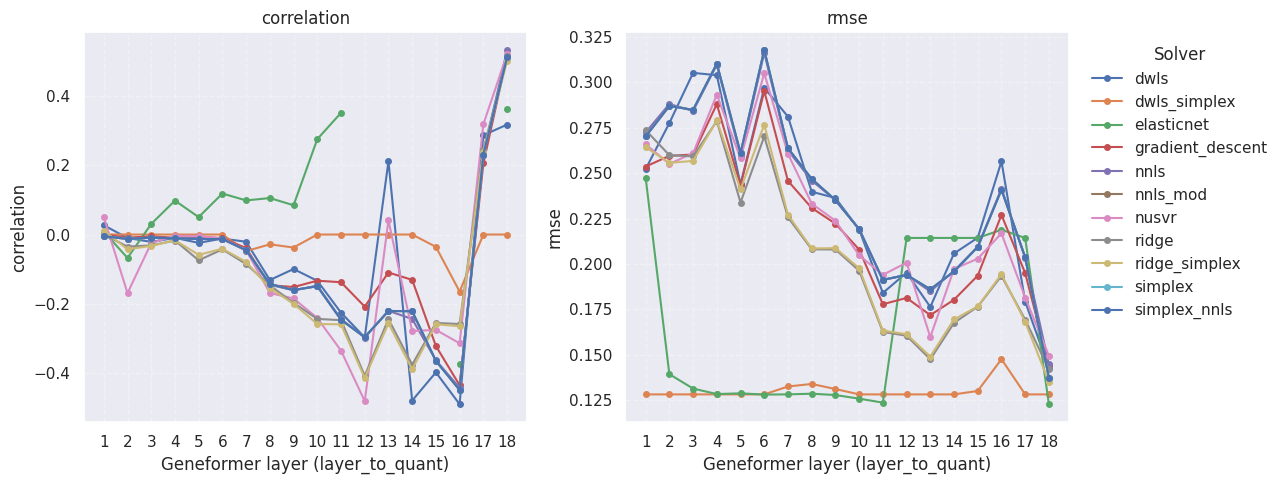

     layer            solver   correlation      rmse  meanCorrelation  \
189     18              dwls  3.173285e-01  0.142648     5.537389e-01   
5        1      dwls_simplex  1.195922e-16  0.128051     3.113182e-16   
194     18        elasticnet  3.619260e-01  0.122603     5.928184e-01   
197     18  gradient_descent  5.146564e-01  0.144127     6.302851e-01   
187     18              nnls  5.325799e-01  0.144532     6.257809e-01   
188     18          nnls_mod  5.114286e-01  0.137121     6.190679e-01   
195     18             nusvr  5.206838e-01  0.149334     5.751300e-01   
193     18             ridge  5.141557e-01  0.141816     6.216540e-01   
191     18     ridge_simplex  4.998204e-01  0.134895     6.184250e-01   
190     18           simplex  5.114216e-01  0.137120     6.190658e-01   
196     18      simplex_nnls  5.114217e-01  0.137120     6.190663e-01   

     meanRMSE  
189  0.133181  
5    0.114588  
194  0.112272  
197  0.114551  
187  0.114008  
188  0.109440  
195  0.1214

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ['correlation', 'rmse']):
    for solver, sub in metrics_df.groupby('solver'):
        sub = sub.sort_values('layer')
        ax.plot(sub['layer'], sub[metric], marker='o', markersize=4, label=solver)
    ax.set_xlabel('Geneformer layer (layer_to_quant)')
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_xticks(range(1, 19))
    ax.grid(alpha=0.3, linestyle='--')
axes[1].legend(title='Solver', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
fig.tight_layout()
fig.savefig('../../results/gf_layer_sweep/layer_sweep_zeroshot_morandini.png', dpi=300, bbox_inches='tight')
plt.show()
print(metrics_df.loc[metrics_df.groupby('solver')['correlation'].idxmax()])

### Fine-tuned

In [11]:
layer_results = {}
metric_rows = []
celltype_rows = []
for layer in range(1, 19):
    print(f'=== layer {layer} ===', flush=True)
    sig_mat_gf_embed = extract_embs(
        bulk_df=signature_df.T,
        mode='geneformer',
        temp_output_dir='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/',
        model_path='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/260624_geneformer_cellClassifier_gf_finetune/ksplit1/',
        delete_temp_files=True,
        layer_to_quant=layer,
    )
    gf_embed = extract_embs(
        bulk_df=bulk_df,
        mode='geneformer',
        temp_output_dir='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/',
        model_path='/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/260624_geneformer_cellClassifier_gf_finetune/ksplit1/',
        delete_temp_files=True,
        layer_to_quant=layer,
    )
    results = run_all_deconv(bulk_df=gf_embed.T, signature_df=sig_mat_gf_embed.T)
    results = {solver: harmonize_columns(df) for solver, df in results.items()}
    layer_results[layer] = results
    for solver, df in results.items():
        samples = df.index.intersection(ground_truth.index)
        celltypes = df.columns.intersection(ground_truth.columns)
        P = df.loc[samples, celltypes].astype(float)
        T = ground_truth.loc[samples, celltypes].astype(float)
        p = P.values.ravel()
        t = T.values.ravel()
        ok = np.isfinite(p) & np.isfinite(t)
        for ct in celltypes:
            a = P[ct].values
            b = T[ct].values
            m = np.isfinite(a) & np.isfinite(b)
            if m.sum() > 1 and np.std(a[m]) > 0 and np.std(b[m]) > 0:
                r_ct = np.corrcoef(a[m], b[m])[0, 1]
            else:
                r_ct = np.nan
            celltype_rows.append({'layer': layer, 'solver': solver, 'celltype': ct, 'correlation': r_ct, 'rmse': np.sqrt(np.mean((a[m] - b[m]) ** 2)) if m.sum() else np.nan})
        ct_sub = [r for r in celltype_rows if r['layer'] == layer and r['solver'] == solver]
        corrs = np.array([r['correlation'] for r in ct_sub], dtype=float)
        mean_corr = np.mean(np.nan_to_num(corrs, nan=0.0))
        mean_rmse = np.nanmean([r['rmse'] for r in ct_sub])
        metric_rows.append({'layer': layer, 'solver': solver, 'correlation': np.corrcoef(p[ok], t[ok])[0, 1], 'rmse': np.sqrt(np.mean((p[ok] - t[ok]) ** 2)), 'meanCorrelation': mean_corr, 'meanRMSE': mean_rmse})

metrics_df = pd.DataFrame(metric_rows)
celltype_df = pd.DataFrame(celltype_rows)

metrics_df.to_csv('../../results/gf_layer_sweep/layer_sweep_metrics_finetuned_morandini.csv', index=False)

=== layer 1 ===
Pseudobulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 24.74it/s]

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.



/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:787: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/geneformer/tokenizer.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  for i in adata.var["ensembl_id_collapsed"][coding_miRNA_loc]
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/geneformer/tokenizer.py:547: FutureWarning: Serie

Loading Geneformer model...


...

Loading tokenized dataset...
Extracting Geneformer embeddings...


  0%|          | 0/4 [00:00<?, ?it/s]

Condition number: 5.44.
~1-10: signatures are well separated; NNLS is usually hard to improve materially with another solver.
Smallest singular value: 0.3721.
If value is close to zero, the signature matrix is ill-conditioned; estimated proportions may be unstable.
Max pairwise cosine similarity between cell types: 0.8445.
Most similar pair: Monocytes vs mDC.
If value is close to 1, these cell types are highly similar and difficult to resolve separately.
Running solver: nnls
Finished in 0.02 seconds.
Running solver: nnls_mod
Finished in 0.02 seconds.
Running solver: dwls
Finished in 0.11 seconds.
Running solver: simplex
Finished in 0.15 seconds.
Running solver: ridge_simplex
Finished in 0.17 seconds.
Running solver: dwls_simplex
Finished in 0.31 seconds.
Running solver: ridge
Finished in 0.09 seconds.
Running solver: elasticnet
Finished in 0.04 seconds.
Running solver: nusvr
Finished in 3.90 seconds.
Running solver: simplex_nnls
Finished in 0.10 seconds.
Running solver: gradient_descen

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/GF_layer_sweep/../../deconversation/deconvolution.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  references = torch.tensor(references, dtype=torch.float32)
/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/GF_layer_sweep/../../deconversation/deconvolution.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mixture = torch.tensor(mixture, dtype=torch.float32)


Finished in 0.52 seconds.


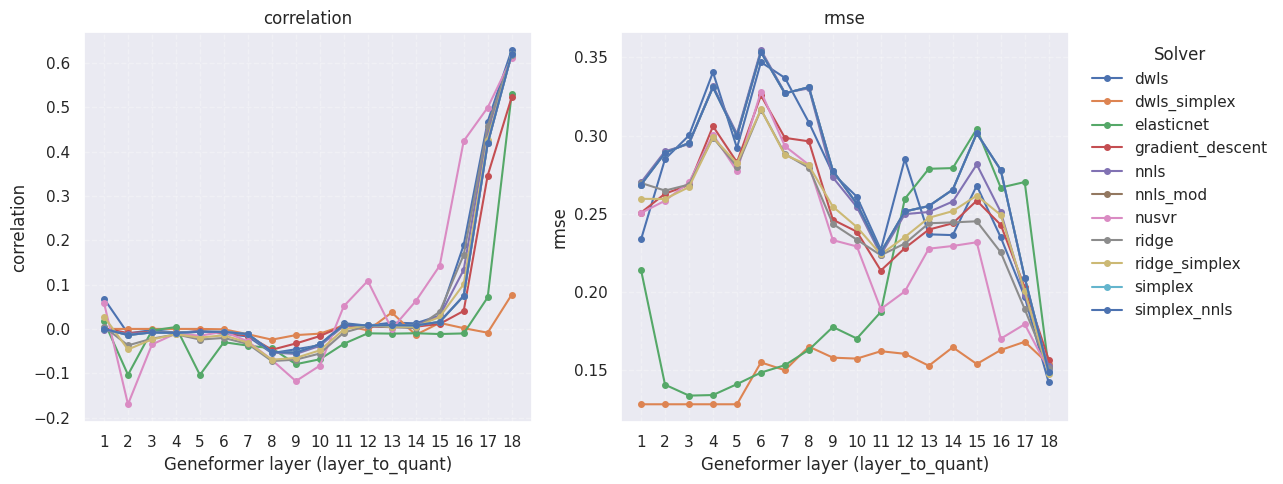

     layer            solver  correlation      rmse  meanCorrelation  meanRMSE
189     18              dwls     0.629481  0.142002         0.511804  0.124845
192     18      dwls_simplex     0.077128  0.153700         0.033774  0.143219
194     18        elasticnet     0.530206  0.151059         0.585517  0.130158
197     18  gradient_descent     0.522754  0.156573         0.600724  0.128404
187     18              nnls     0.615867  0.152278         0.602436  0.127923
188     18          nnls_mod     0.620425  0.148713         0.615037  0.124614
195     18             nusvr     0.611260  0.150085         0.585127  0.124529
193     18             ridge     0.617177  0.150974         0.604639  0.126940
191     18     ridge_simplex     0.619931  0.147663         0.617538  0.123731
190     18           simplex     0.620426  0.148712         0.615040  0.124613
196     18      simplex_nnls     0.620426  0.148712         0.615040  0.124613


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ['correlation', 'rmse']):
    for solver, sub in metrics_df.groupby('solver'):
        sub = sub.sort_values('layer')
        ax.plot(sub['layer'], sub[metric], marker='o', markersize=4, label=solver)
    ax.set_xlabel('Geneformer layer (layer_to_quant)')
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_xticks(range(1, 19))
    ax.grid(alpha=0.3, linestyle='--')
axes[1].legend(title='Solver', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
fig.tight_layout()
fig.savefig('../../results/gf_layer_sweep/layer_sweep_finetuned_morandini.png', dpi=300, bbox_inches='tight')
plt.show()
print(metrics_df.loc[metrics_df.groupby('solver')['correlation'].idxmax()])

In [26]:
ground_truth.shape

(156, 4)